In [1]:
import os
import sys
sys.path.append(os.path.abspath("../../.."))

In [2]:
import pandas as pd
from classes.trading.actionPredictionTrading import ActionPredictionTrading

# Load the dataset
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
df = pd.read_csv(csv_path, parse_dates=['Date'])

test_start_date = '2019-01-01'

# Filtra o conjunto de teste
test_data = df[df['Date'] >= test_start_date]

In [3]:


# List of stocks and paths to models and scalers
stocks_models_scalers = {
    "ITUB4": {
        "model_path": "../../../saved_models/ITUB4_model_v1.1.pkl",
        "scaler_x_path": "../../../saved_models/ITUB4_scaler_X_v1.1.pkl"
    },
    "VALE3": {
        "model_path": "../../../saved_models/VALE3_model_v1.1.pkl",
        "scaler_x_path": "../../../saved_models/VALE3_scaler_X_v1.1.pkl"
    },
}


In [4]:
# Iterate over each stock
results = {}
for stock, paths in stocks_models_scalers.items():
    print(f"Analyzing stock: {stock}")
    analysis = ActionPredictionTrading(
        test_data, stock, model_path=paths["model_path"]
    )
    analysis.load_model()
    if "scaler_x_path" in paths:
        analysis.load_scaler(paths["scaler_x_path"])
    analysis.generate_predictions()
    result_no_stop = analysis.simulate_trading(stop_loss=False,  stop_type='percent', stop_value=0.02)
    result_with_stop = analysis.simulate_trading(stop_loss=True,  stop_type='percent', stop_value=0.02)
    results[stock] = {
        'no_stop_loss': result_no_stop,
        'with_stop_loss': result_with_stop
    }

# Display results
for stock, result in results.items():
    print(f"\nResults for {stock}:")
    print(f"No Stop Loss: {result['no_stop_loss']}")
    print(f"With Stop Loss: {result['with_stop_loss']}")

Analyzing stock: ITUB4
Model loaded from ../../../saved_models/ITUB4_model_v1.1.pkl
Scaler loaded from ../../../saved_models/ITUB4_scaler_X_v1.1.pkl
Analyzing stock: VALE3
Model loaded from ../../../saved_models/VALE3_model_v1.1.pkl
Scaler loaded from ../../../saved_models/VALE3_scaler_X_v1.1.pkl

Results for ITUB4:
No Stop Loss: {'total_return': 0.004306758880615234, 'hit_rate': 0.5091693635382956, 'sharpe_ratio': 0.009284510031766181, 'max_drawdown': 1115.049934387207, 'final_capital': 100430.67588806152, 'stop_triggered': 0, 'limits': []}
With Stop Loss: {'total_return': 0.04480917984008789, 'hit_rate': 0.5091693635382956, 'sharpe_ratio': 0.11219380870429702, 'max_drawdown': 487.46888732910156, 'final_capital': 104480.91798400879, 'stop_triggered': 254, 'limits': []}

Results for VALE3:
No Stop Loss: {'total_return': -0.026297760009765626, 'hit_rate': 0.4929881337648328, 'sharpe_ratio': -0.022843905582388878, 'max_drawdown': 6160.866165161133, 'final_capital': 97370.22399902344, 'st

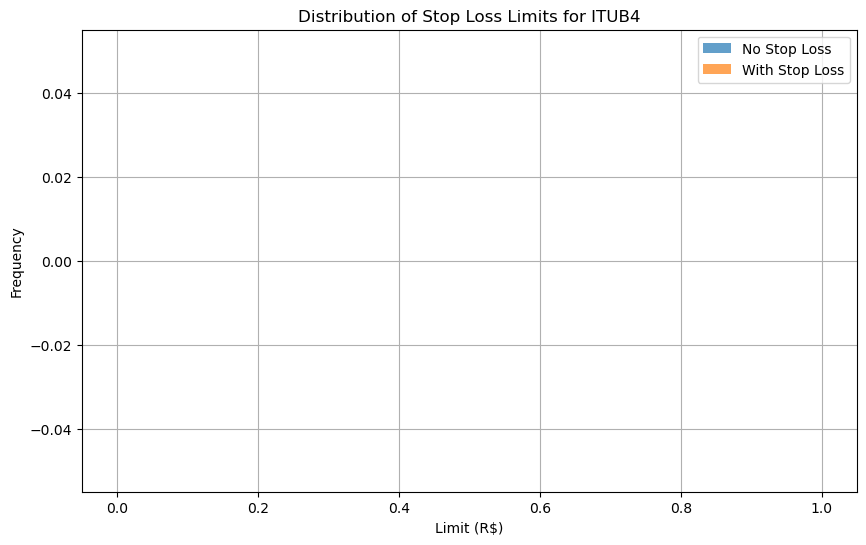

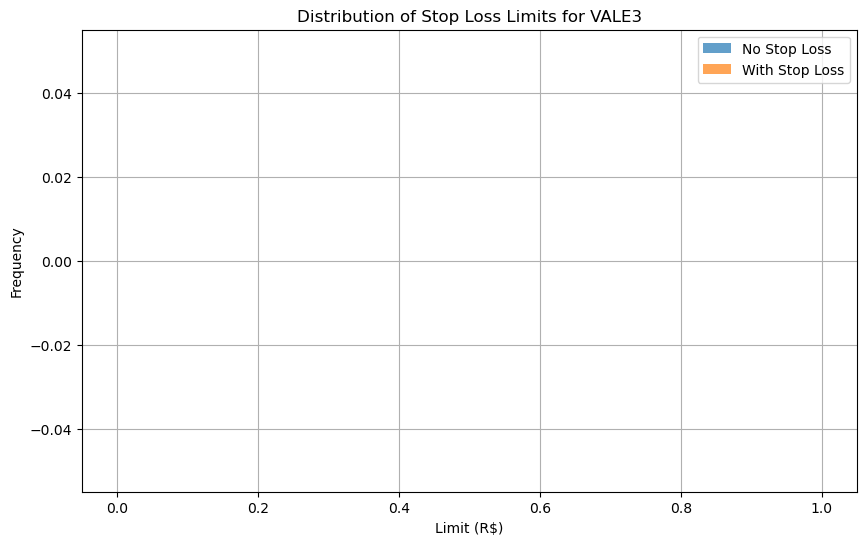

In [5]:
import matplotlib.pyplot as plt

# Iterate over each stock and plot the limits
for stock, result in results.items():
    limits_no_stop = result['no_stop_loss']['limits']
    limits_with_stop = result['with_stop_loss']['limits']
    
    # Plot the distribution of limits for no stop loss
    plt.figure(figsize=(10, 6))
    plt.hist(limits_no_stop, bins=50, alpha=0.7, label="No Stop Loss")
    plt.hist(limits_with_stop, bins=50, alpha=0.7, label="With Stop Loss")
    plt.title(f"Distribution of Stop Loss Limits for {stock}")
    plt.xlabel("Limit (R$)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()